https://www.youtube.com/watch?v=BV0YUeam4y8&t=1557s

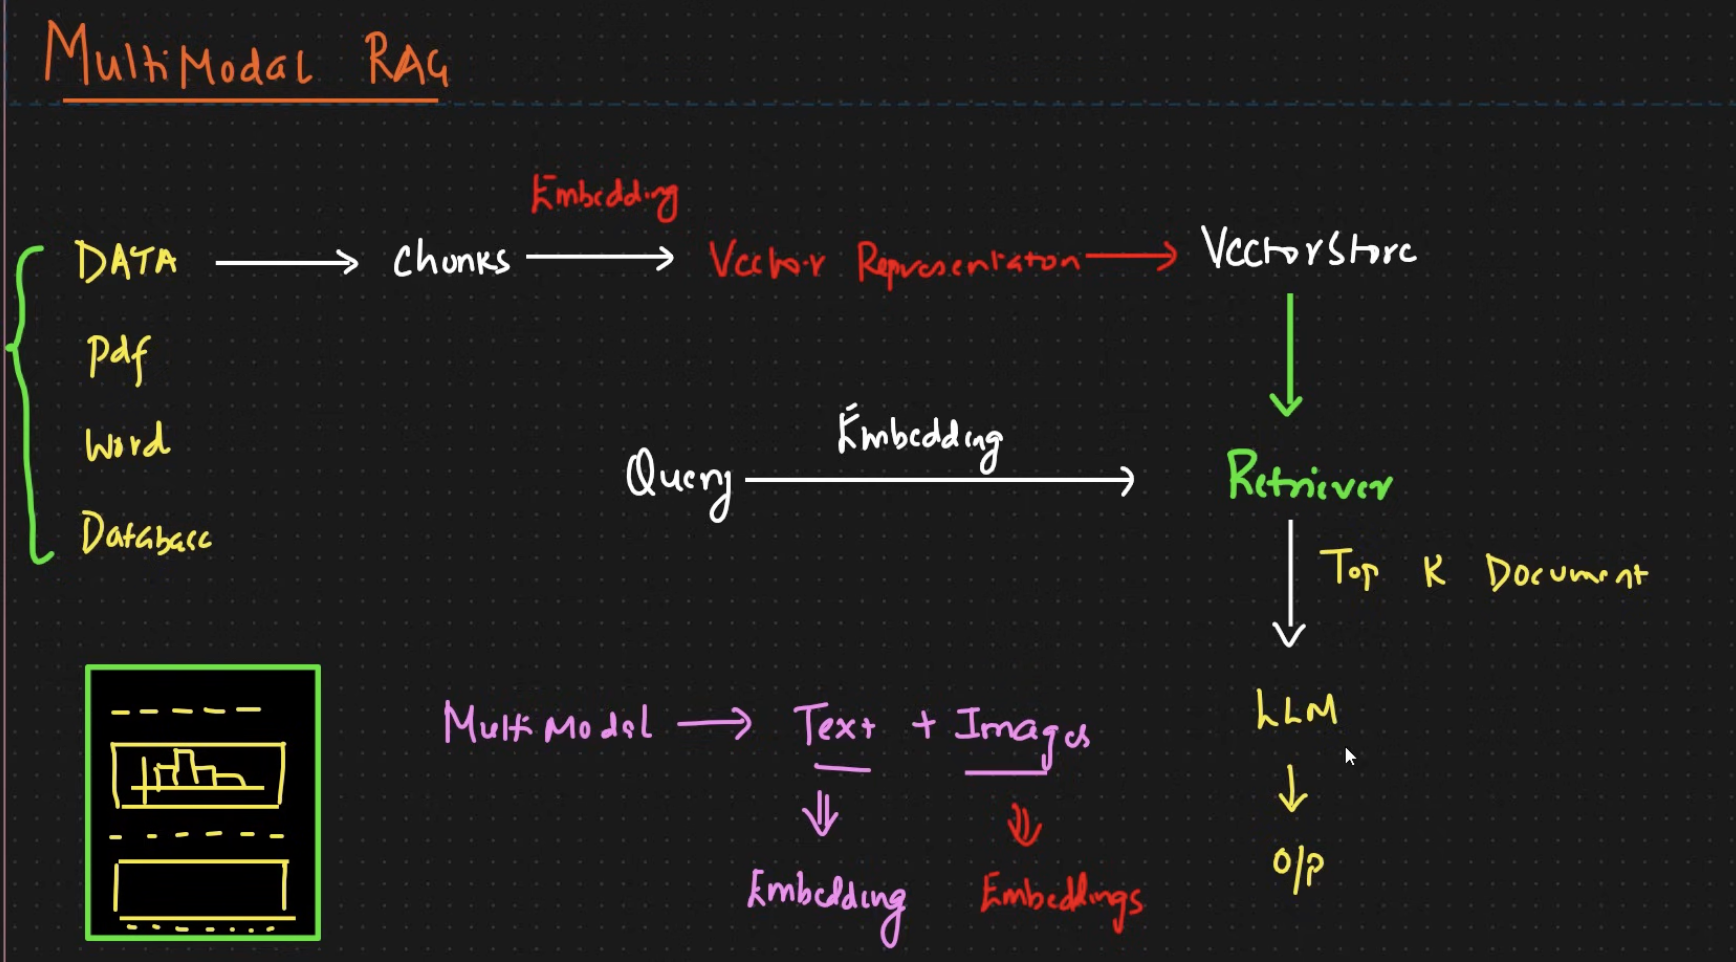

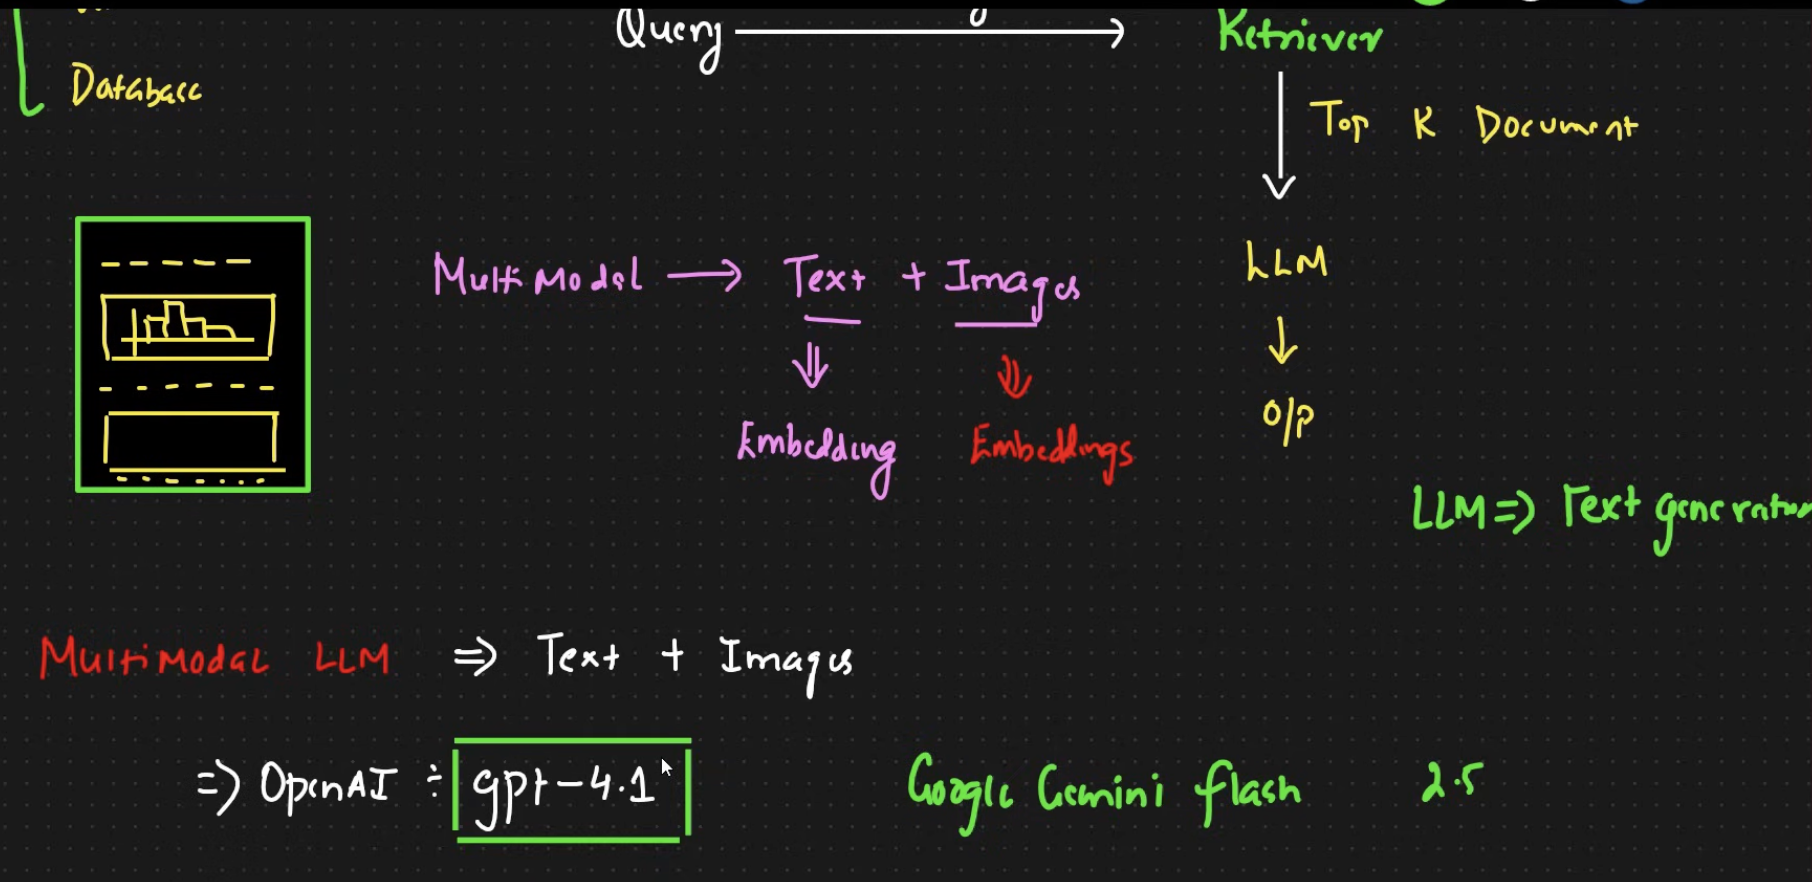

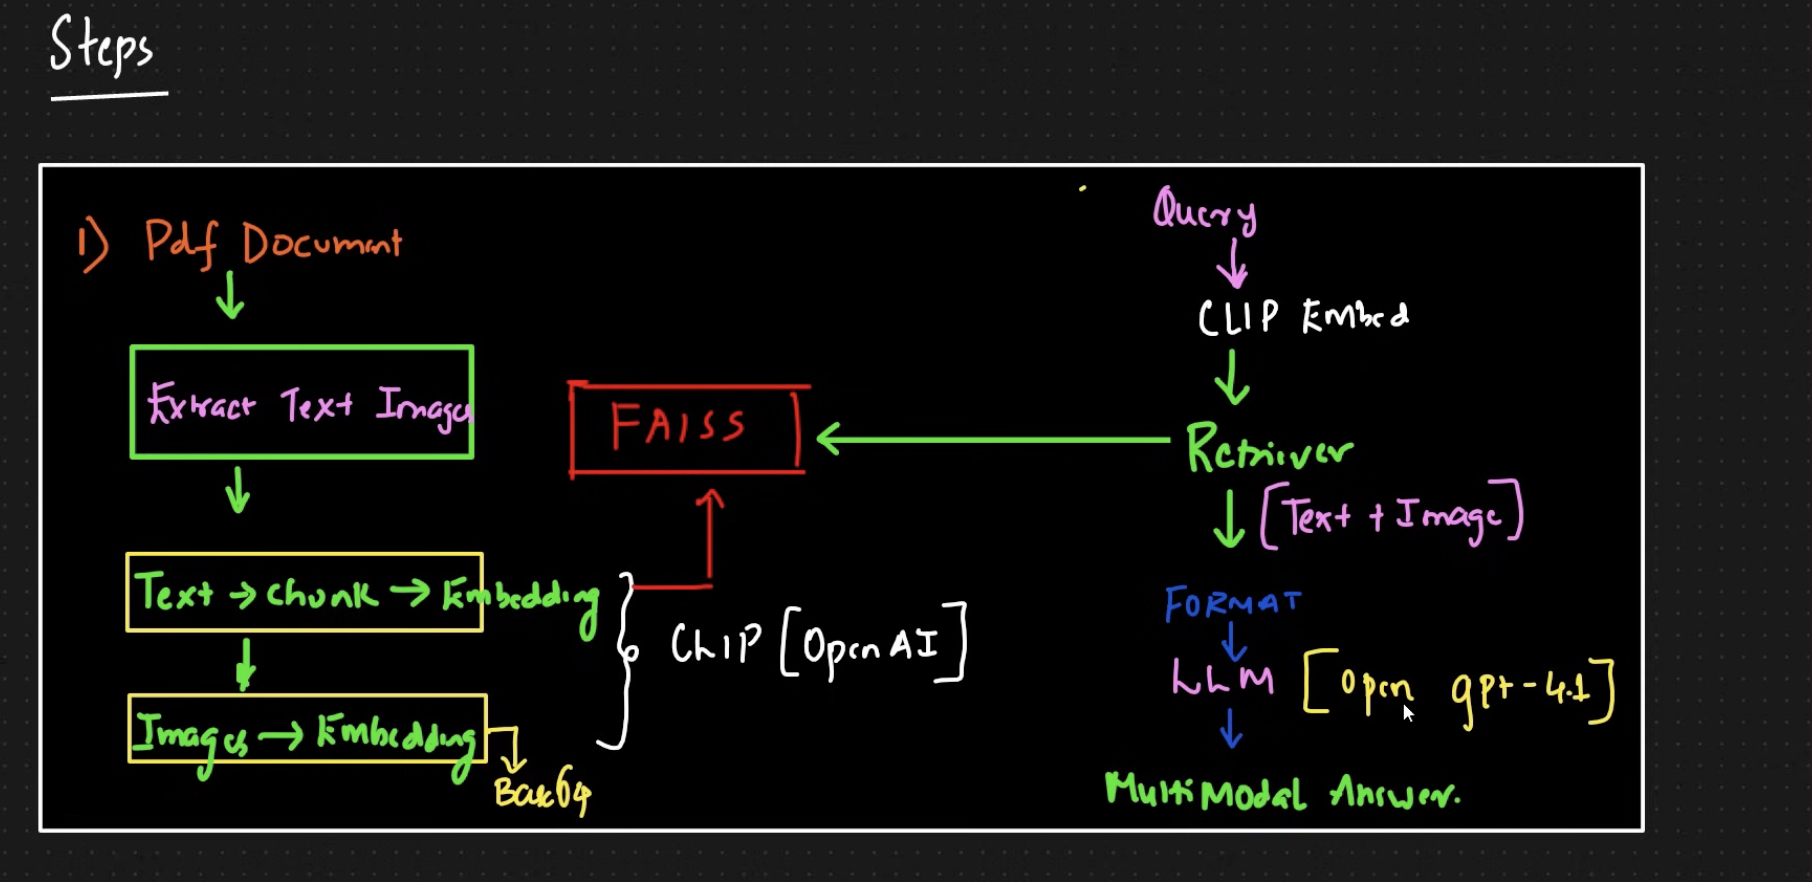

### Multimodal RAG (PDF With Images)

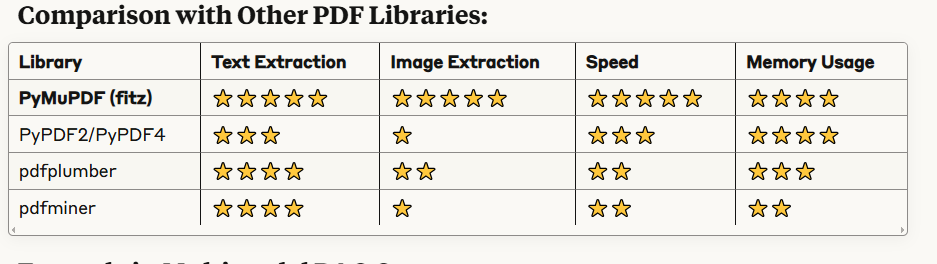

#python 3.10.13 version will support

In [1]:
#!pip install pymupdf

In [2]:
import sys
print(sys.version)
print(sys.executable)

3.10.13 (main, Jun 26 2025, 17:33:11) [Clang 17.0.0 (clang-1700.0.13.5)]
/Users/gvijaykumarachary/.pyenv/versions/3.10.13/bin/python


In [3]:
import fitz  # PyMuPDF
from langchain_core.documents import Document
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch
import numpy as np
from langchain.chat_models import init_chat_model
# from langchain.prompts import PromptTemplate
# from langchain.schema.messages import HumanMessage
from langchain_core.messages import HumanMessage
# from sklearn.metrics.pairwise import cosine_similarity
import os
import base64
import io
# from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

In [4]:
###Clip Model
import os
from dotenv import load_dotenv
load_dotenv()

## set up the environment
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

### initialize the Clip Model for unified embeddings

# CLIPModel encodes both into a shared embedding space for similarity and retrieval.
clip_model=CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
# CLIPProcessor prepares text and images for the model.
clip_processor=CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [ ]:
### Embedding functions
# Defines a function that converts an image into a numeric embedding vector.
# This function takes an image, preprocesses it with CLIPProcessor, encodes it with CLIPModel, normalizes the embedding, and returns a NumPy vector ready for similarity search.
def embed_image(image_data):
    # Documentation string describing the purpose of the function.
    """Embed image using CLIP"""
    # Checks whether the input is a file path (string).
    if isinstance(image_data, str):  # If path
        # Loads the image from disk and converts it to a 3-channel RGB format.
        image = Image.open(image_data).convert("RGB")
    else:  # If PIL Image
        # Uses the provided PIL image directly without reloading.
        image = image_data
    # Preprocesses the image (resize, normalize, tensorize) into PyTorch tensors suitable for the CLIP model.
    # A Tensor is a multi-dimensional array of numbers. It is the basic data structure used in machine learning and deep learning frameworks like TensorFlow and PyTorch.
    inputs=clip_processor(images=image,return_tensors="pt")
    # Disables gradient tracking to reduce memory and speed up inference.
    with torch.no_grad():
        # Runs the CLIP image encoder and returns the image embedding vector.
        features = clip_model.get_image_features(**inputs)
        # Normalize embeddings to unit vector
        # Normalizes the embedding to unit length so cosine similarity becomes a dot product.
        features = features / features.norm(dim=-1, keepdim=True)
        # Removes extra batch dimensions and converts the tensor to a NumPy array for storage or vector search.
        return features.squeeze().numpy()
    
def embed_text(text):
    """Embed text using CLIP."""
    inputs = clip_processor(
        text=text, 
        # Requests the output to be returned as PyTorch tensors.
        return_tensors="pt", 
        padding=True,
        # Truncates text that is longer than the model’s allowed length.
        truncation=True,
        max_length=77  # CLIP's max token length
    )
    with torch.no_grad():
        features = clip_model.get_text_features(**inputs)
        # Normalize embeddings
        features = features / features.norm(dim=-1, keepdim=True)
        return features.squeeze().numpy()

In [6]:
## Process PDF
# pdf_path="multimodal_sample.pdf"
pdf_path="attention-is-all-you-need.pdf"
doc=fitz.open(pdf_path)
# Storage for all documents and embeddings
all_docs = []
all_embeddings = []
image_data_store = {}  # Store actual image data for LLM

# Text splitter
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)




In [7]:
doc

Document('attention-is-all-you-need.pdf')

In [8]:
for i,page in enumerate(doc):
    ## process text
    text=page.get_text()
    if text.strip():
        ##create temporary document for splitting
        temp_doc = Document(page_content=text, metadata={"page": i, "type": "text"})
        text_chunks = splitter.split_documents([temp_doc])

        #Embed each chunk using CLIP
        for chunk in text_chunks:
            embedding = embed_text(chunk.page_content)
            all_embeddings.append(embedding)
            all_docs.append(chunk)



    ## process images
    ##Three Important Actions:

    ##Convert PDF image to PIL format
    ##Store as base64 for GPT-4V (which needs base64 images)
    ##Create CLIP embedding for retrieval

    for img_index, img in enumerate(page.get_images(full=True)):
        try:
            xref = img[0]
            base_image = doc.extract_image(xref)
            image_bytes = base_image["image"]
            
            # Convert to PIL Image
            pil_image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
            
            # Create unique identifier
            image_id = f"page_{i}_img_{img_index}"
            
            # Store image as base64 for later use with GPT-4V
            buffered = io.BytesIO()
            pil_image.save(buffered, format="PNG")
            img_base64 = base64.b64encode(buffered.getvalue()).decode()
            image_data_store[image_id] = img_base64
            
            # Embed image using CLIP
            embedding = embed_image(pil_image)
            all_embeddings.append(embedding)
            
            # Create document for image
            image_doc = Document(
                page_content=f"[Image: {image_id}]",
                metadata={"page": i, "type": "image", "image_id": image_id}
            )
            all_docs.append(image_doc)
            
        except Exception as e:
            print(f"Error processing image {img_index} on page {i}: {e}")
            continue

doc.close()


In [9]:
all_docs

[Document(metadata={'page': 0, 'type': 'text'}, page_content='Provided proper attribution is provided, Google hereby grants permission to\nreproduce the tables and figures in this paper solely for use in journalistic or\nscholarly works.\nAttention Is All You Need\nAshish Vaswani∗\nGoogle Brain\navaswani@google.com\nNoam Shazeer∗\nGoogle Brain\nnoam@google.com\nNiki Parmar∗\nGoogle Research\nnikip@google.com\nJakob Uszkoreit∗\nGoogle Research\nusz@google.com\nLlion Jones∗\nGoogle Research\nllion@google.com\nAidan N. Gomez∗†\nUniversity of Toronto\naidan@cs.toronto.edu'),
 Document(metadata={'page': 0, 'type': 'text'}, page_content='Google Research\nllion@google.com\nAidan N. Gomez∗†\nUniversity of Toronto\naidan@cs.toronto.edu\nŁukasz Kaiser∗\nGoogle Brain\nlukaszkaiser@google.com\nIllia Polosukhin∗‡\nillia.polosukhin@gmail.com\nAbstract\nThe dominant sequence transduction models are based on complex recurrent or\nconvolutional neural networks that include an encoder and a decoder. The

In [10]:
# Create unified FAISS vector store with CLIP embeddings
embeddings_array = np.array(all_embeddings)
embeddings_array

array([[ 0.03500306,  0.00810927, -0.03526153, ...,  0.02110529,
         0.00167523, -0.03087724],
       [ 0.00678687, -0.00609656, -0.04333363, ..., -0.03352839,
        -0.02618881, -0.01386965],
       [ 0.0003751 , -0.02122342, -0.00457741, ..., -0.01093396,
         0.03803126, -0.0266316 ],
       ...,
       [-0.01654974, -0.04369034,  0.03837437, ..., -0.01301269,
         0.00746537, -0.07073218],
       [-0.0192853 ,  0.00096112,  0.00146916, ..., -0.03778005,
         0.02002618,  0.00973866],
       [-0.01122876, -0.02954059,  0.0286065 , ..., -0.03015947,
         0.02209012,  0.0003666 ]], shape=(106, 512), dtype=float32)

In [11]:
(all_docs,embeddings_array)

([Document(metadata={'page': 0, 'type': 'text'}, page_content='Provided proper attribution is provided, Google hereby grants permission to\nreproduce the tables and figures in this paper solely for use in journalistic or\nscholarly works.\nAttention Is All You Need\nAshish Vaswani∗\nGoogle Brain\navaswani@google.com\nNoam Shazeer∗\nGoogle Brain\nnoam@google.com\nNiki Parmar∗\nGoogle Research\nnikip@google.com\nJakob Uszkoreit∗\nGoogle Research\nusz@google.com\nLlion Jones∗\nGoogle Research\nllion@google.com\nAidan N. Gomez∗†\nUniversity of Toronto\naidan@cs.toronto.edu'),
  Document(metadata={'page': 0, 'type': 'text'}, page_content='Google Research\nllion@google.com\nAidan N. Gomez∗†\nUniversity of Toronto\naidan@cs.toronto.edu\nŁukasz Kaiser∗\nGoogle Brain\nlukaszkaiser@google.com\nIllia Polosukhin∗‡\nillia.polosukhin@gmail.com\nAbstract\nThe dominant sequence transduction models are based on complex recurrent or\nconvolutional neural networks that include an encoder and a decoder. T

In [12]:
#!pip install faiss-cpu

In [13]:

##Create custom FAISS index since we have precomputed embeddings
vector_store = FAISS.from_embeddings(
    text_embeddings=[(doc.page_content, emb) for doc, emb in zip(all_docs, embeddings_array)],
    embedding=None,  # We're using precomputed embeddings
    metadatas=[doc.metadata for doc in all_docs]
)
vector_store

`embedding_function` is expected to be an Embeddings object, support for passing in a function will soon be removed.


In [14]:
# Initialize GPT-4 Vision model
llm = init_chat_model("openai:gpt-4.1")
llm

ChatOpenAI(profile={'max_input_tokens': 1047576, 'max_output_tokens': 32768, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x1626f5210>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x16467a080>, root_client=<openai.OpenAI object at 0x163437a90>, root_async_client=<openai.AsyncOpenAI object at 0x164679fc0>, model_name='gpt-4.1', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

In [15]:
# Defines a function that retrieves the top-k most relevant items for a query.
def retrieve_multimodal(query, k=5):
    """Unified retrieval using CLIP embeddings for both text and images."""
    # Embed query using CLIP
    # Comment indicating the query will be converted into a CLIP embedding.
    # Converts the input text query into a vector embedding using your embed_text() function.
    query_embedding = embed_text(query)
    
    # Search in unified vector store
    # Calls the vector store API to search using a raw embedding vector instead of raw text.
    results = vector_store.similarity_search_by_vector(
        # Passes the query embedding as the search vector.
        embedding=query_embedding,
        # Specifies how many nearest results (top-k) should be returned.
        k=k
    )
    
    return results

In [16]:
def create_multimodal_message(query, retrieved_docs):
    """Create a message with both text and images for GPT-4V."""
    content = []
    
    # Add the query
    content.append({
        "type": "text",
        "text": f"Question: {query}\n\nContext:\n"
    })
    
    # Separate text and image documents
    text_docs = [doc for doc in retrieved_docs if doc.metadata.get("type") == "text"]
    image_docs = [doc for doc in retrieved_docs if doc.metadata.get("type") == "image"]
    
    # Add text context
    if text_docs:
        text_context = "\n\n".join([
            f"[Page {doc.metadata['page']}]: {doc.page_content}"
            for doc in text_docs
        ])
        content.append({
            "type": "text",
            "text": f"Text excerpts:\n{text_context}\n"
        })
    
    # Add images
    for doc in image_docs:
        image_id = doc.metadata.get("image_id")
        if image_id and image_id in image_data_store:
            content.append({
                "type": "text",
                "text": f"\n[Image from page {doc.metadata['page']}]:\n"
            })
            content.append({
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/png;base64,{image_data_store[image_id]}"
                }
            })
    
    # Add instruction
    content.append({
        "type": "text",
        "text": "\n\nPlease answer the question based on the provided text and images."
    })
    
    return HumanMessage(content=content)

In [17]:
def multimodal_pdf_rag_pipeline(query):
    """Main pipeline for multimodal RAG."""
    # Retrieve relevant documents
    context_docs = retrieve_multimodal(query, k=5)
    
    # Create multimodal message
    message = create_multimodal_message(query, context_docs)
    
    # Get response from GPT-4V
    response = llm.invoke([message])
    
    # Print retrieved context info
    print(f"\nRetrieved {len(context_docs)} documents:")
    for doc in context_docs:
        doc_type = doc.metadata.get("type", "unknown")
        page = doc.metadata.get("page", "?")
        if doc_type == "text":
            preview = doc.page_content[:100] + "..." if len(doc.page_content) > 100 else doc.page_content
            print(f"  - Text from page {page}: {preview}")
        else:
            print(f"  - Image from page {page}")
    print("\n")
    
    return response.content

In [18]:
if __name__ == "__main__":
    # Example multimodal_sample.pdf queries
    # queries = [
    #     "What does the chart on page 1 show about revenue trends?",
    #     "Summarize the main findings from the document",
    #     "What visual elements are present in the document?"
    # ]
    
    # Example attention-is-all-you-need queries
      #Basic Architecture Questions

    queries = [
        "What are the two main components of the Transformer architecture?",
        "How many layers does the base Transformer model use in both encoder and decoder? ",
        "What is the dimensionality (dmodel) used in the base Transformer model? "
    ]

      #Attention Mechanism Questions
    #    queries = [
    #     "What is the formula for Scaled Dot-Product Attention? ",
    #     "Why do the authors scale the dot products by 1/√dk in their attention mechanism? ",
    #     "How many attention heads does the Transformer use, and what is the dimension of each head? "
    # ]

        #Comparative Analysis Question
        
    #     queries = [
    #     "According to Table 1, what are the main advantages of self-attention layers compared to recurrent and convolutional layers in terms of computational complexity and parallelization? "
    # ]

    
    for query in queries:
        print(f"\nQuery: {query}")
        print("-" * 50)
        answer = multimodal_pdf_rag_pipeline(query)
        print(f"Answer: {answer}")
        print("=" * 70)


Query: What are the two main components of the Transformer architecture?
--------------------------------------------------


/Users/gvijaykumarachary/.pyenv/versions/3.10.13/lib/python3.10/site-packages/pydantic/v1/main.py:1054: UserWarning: LangSmith now uses UUID v7 for run and trace identifiers. This warning appears when passing custom IDs. Please use: from langsmith import uuid7
            id = uuid7()
Future versions will require UUID v7.
  input_data = validator(cls_, input_data)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



Retrieved 5 documents:
  - Text from page 1: To the best of our knowledge, however, the Transformer is the first transduction model relying
entir...
  - Text from page 1: In this work we propose the Transformer, a model architecture eschewing recurrence and instead
relyi...
  - Text from page 1: Attention mechanisms have become an integral part of compelling sequence modeling and transduc-
tion...
  - Text from page 8: (section 5.4), learning rates and beam size on the Section 22 development set, all other parameters
...
  - Text from page 9: For translation tasks, the Transformer can be trained significantly faster than architectures based
...


Answer: Based on the provided excerpts, **the two main components of the Transformer architecture are:**

1. **Encoder**
2. **Decoder**

As noted in Page 1, "Most competitive neural sequence transduction models have an encoder-decoder structure," and the Transformer follows this design. The encoder processes the input sequence and the decoder